In [1]:
# ==========================================
# 1. Standard Library Imports
# ==========================================
import os
import sys
import csv
import time
import pickle
import random
import warnings
import itertools
import textwrap
import re
from collections import Counter

# ==========================================
# 2. Third-Party Scientific Imports
# ==========================================
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats
import scipy.linalg as linalg
import scipy.optimize as optimize
import scipy.fft as fft
import scipy.signal as signal
from scipy.interpolate import interp1d
from scipy.stats import pearsonr, skewnorm

# Specialized Science Toolkits
import pywt
import pycwt as wavelet
import emd
from eofs.standard import Eof
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

# Machine Learning (Scikit-Learn)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, PolynomialFeatures, normalize
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedShuffleSplit, 
    cross_val_score, KFold, LeaveOneOut, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, 
    roc_curve, accuracy_score, classification_report, mean_squared_error
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn import tree

# ==========================================
# 3. Visualization & Plotting
# ==========================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
import seaborn as sns
import imgkit
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import BoundaryNorm
from colorama import Fore, Back, Style

# Geospatial Plotting
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.util import add_cyclic_point

# ==========================================
# 4. Configuration & Local Modules
# ==========================================
warnings.filterwarnings('ignore')
sns.set_theme() # Optional: sets a cleaner default style for plots

# Define Paths
HURDAT_CODE_PATH = '/Users/jackskari/Desktop/NCSU_Research/Modularized_Code/'
DATA_FILE_PATH = "/Users/jackskari/Desktop/NCSU_Research/New_Data_2025/hurr2025.csv"

# Dynamic import of local module
if HURDAT_CODE_PATH not in sys.path:
    sys.path.append(HURDAT_CODE_PATH)

try:
    import ReadHurdatData
except ImportError:
    print(f"Error: Could not find ReadHurdatData at {HURDAT_CODE_PATH}")

# ==========================================
# 5. Data Loading & Initial Processing
# ==========================================
df = pd.read_csv(DATA_FILE_PATH)

# Load Near-Land Data
(nearmod_df, nearseasonal_ace, nearseasonal_num, nearseasonal_dur, 
 nearseasonal_apsm, nearseasonal_ap6h, nearseasonal_avdur, nearmonthly_ace, 
 nearseasonal_avmaxwind, nearseasonal_hurr, nearseasonal_mh, nearseasonal_hu, 
 nearseasonal_mjhu, yearz) = ReadHurdatData.hurdatclean(df, 1, 12, landmask=1, nearland=2)

# Load Standard Seasonal Data
(mod_df, seasonal_ace, seasonal_num, seasonal_dur, 
 seasonal_apsm, seasonal_ap6h, seasonal_avdur, monthly_ace, 
 seasonal_avmaxwind, seasonal_hurr, seasonal_mh, seasonal_hu, 
 seasonal_mjhu, yearz) = ReadHurdatData.hurdatclean(df, 1, 12)

# Slicing Indices (100+)
yearzz = np.asarray(yearz[100:])
ace_prime = seasonal_ace[100:]
num_prime = seasonal_num[100:]

nearace_prime = nearseasonal_ace[100:]
nearnum_prime = nearseasonal_num[100:]

# Random Forest Model Setup

In [2]:
# ==========================================
# 1. Categorization Functions
# ==========================================

def get_activity_categories(data_list, reference_list, year_labels):
    """
    Categorizes years into High, Mid, or Low activity based on quartiles.
    
    Args:
        data_list: The values to categorize.
        reference_list: The baseline values used to calculate percentiles (e.g., a training period).
        year_labels: List of years corresponding to the data_list.
    """
    q1 = np.percentile(reference_list, 25)
    q3 = np.percentile(reference_list, 75)

    # Use NumPy select for fast, readable conditional mapping
    conditions = [
        (data_list <= q1),
        (data_list >= q3)
    ]
    scores = [0, 2] # 0: Low, 2: High
    
    # Default is 1 (Mid)
    final_scores = np.select(conditions, scores, default=1)
    
    # Filter years into separate lists for research analysis
    low  = [year_labels[i] for i, s in enumerate(final_scores) if s == 0]
    mid  = [year_labels[i] for i, s in enumerate(final_scores) if s == 1]
    high = [year_labels[i] for i, s in enumerate(final_scores) if s == 2]

    return high, mid, low, final_scores


def get_extended_categories(data_list, reference_list, year_labels, bound=2.0):
    """
    Categorizes years into Hyperactive, High, Mid, or Low activity.
    """
    q1 = np.percentile(reference_list, 33)
    q3 = np.percentile(reference_list, 67)
    high_threshold = bound * np.median(reference_list)

    conditions = [
        (data_list < q1),                               # Low
        (data_list >= q3) & (data_list <= high_threshold), # High
        (data_list > high_threshold)                    # Very High (Hyperactive)
    ]
    scores = [0, 2, 3] # 0:Low, 2:High, 3:Very High
    
    final_scores = np.select(conditions, scores, default=1) # Default 1: Mid

    # Organize years
    low  = [year_labels[i] for i, s in enumerate(final_scores) if s == 0]
    mid  = [year_labels[i] for i, s in enumerate(final_scores) if s == 1]
    high = [year_labels[i] for i, s in enumerate(final_scores) if s == 2]
    v_high = [year_labels[i] for i, s in enumerate(final_scores) if s == 3]

    return v_high, high, mid, low, final_scores

# ==========================================
# 2. Path Configuration & Data Loading
# ==========================================

BASE_DIR = "/Users/jackskari/Desktop/NCSU_Research/ML_Data_Classes"

# Load Pickled Data
with open(f"{BASE_DIR}/truedata1950-2025.pkl", 'rb') as f:
    pure_data = pickle.load(f)

# Load DataFrames and clean "Unnamed" columns immediately


ace_df = pd.read_csv(f"{BASE_DIR}/clusteredace.csv", index_col=0)
coast_ace_df = pd.read_csv(f"{BASE_DIR}/clusteredcoastace.csv", index_col=0)

with open(f"{BASE_DIR}/cpcclass.pkl", 'rb') as f:
    activity_class = pickle.load(f)


# ==========================================
# 3. Variable Initialization
# ==========================================

# Feature Names
feature_names = ['amm', 'amo', 'ao', 'censo', 'dm', 'epo', 'ggst', 'ngst', 'sgst',
    'mdrolr', 'mdrslp', 'mdrsst', 'nao', 'pdo', 'pna', 'qbo', 'sfi', 'soi', 'tni', 
    'tna', 'tsa', 'whwp', 'wpi', 'nino12', 'nino3', 'nino34', 'nino4', 'mei', 'roni', 
    'sahel', 'mdru200', 'mdru850', 'mdrv200', 'mdrv850', 'mdrvws', 'gomu200', 'gomu850',
    'gomv200', 'gomv850', 'gomvws', 'mdrt200', 'gomolr', 'gomslp', 'rhsal', 'nino34_forecast'
]

# Extract activity class components
(hyper_years, above_years, average_years, below_years, 
 score_data, actualscore) = activity_class[:6]

activity_bins = [below_years, average_years, above_years, hyper_years]
type_labels = ["Below Average", "Average", "Above Average", "Hyperactive"]

# ==========================================
# 4. Scenario Logic (Coastal vs General)
# ==========================================

COAST_MODE = 0
features = ace_df
class_type = 'CPC'

if COAST_MODE == 1:
    vhigh, high, mid, low, scores = get_extended_categories(
        nearace_prime, 
        nearace_prime[:70], 
        year_labels=yearzz, 
        bound=2
    )
    features = coast_ace_df
    actualscore = np.asarray(scores)
    class_type = 'CHACE'
# Metadata for plotting/exports
months_order = ['JUN','JUL','AUG','SEP','OCT','NOV','DEC','JAN','FEB','MAR','APR','MAY']

climperiod=30
if climperiod==30:
    startyear=0
else:
    startyear=0
typecast = np.array([0,1,2,3])

paramfeeder=None

# Load in Data

In [4]:
# To prevent the model from using things it shouldn't be
if (class_type != 'CPC') and (class_type != 'CHACE'):
    raise Exception('Choose classification set the model will use')


if class_type=='CPC':
    with open(f'{BASE_DIR}/rawrefinedcpc.pkl', "rb") as file:
        classset = pickle.load(file)
elif class_type=='CHACE':
    with open(f'{BASE_DIR}/rawrefinedchace.pkl', "rb") as file:
        classset = pickle.load(file)


print(f'Classification Approach: {class_type}')

# Structured as {month, features, parameters, H-Skill, and shorter climatology H-Skill}, for December to June

Classification Approach: CPC


# Feature Names and Locations/Types

In [6]:
feature_names = ['amm', 'amo', 'ao', 'censo', 'dm', 'epo', 'ggst', 'ngst', 'sgst',
    'mdrolr', 'mdrslp', 'mdrsst', 'nao', 'pdo', 'pna', 'qbo', 'sfi', 'soi', 'tni', 
    'tna', 'tsa', 'whwp', 'wpi', 'nino12', 'nino3', 'nino34', 'nino4', 'mei', 'roni', 
    'sahel', 'mdru200', 'mdru850', 'mdrv200', 'mdrv850', 'mdrvws', 'gomu200', 'gomu850',
    'gomv200', 'gomv850', 'gomvws', 'mdrt200', 'gomolr', 'gomslp', 'rhsal', 'nino34_forecast'
]

atlnames=['amm', 'amo', 'ao', 'dm', 'mdrolr', 
    'mdrslp', 'mdrsst', 'gomolr', 'gomslp', 'rhsal', 
    'nao', 'sfi', 'tna', 'tsa', 'sahel'
]
pacnames=['censo', 'epo', 'pdo', 'pna',  
    'soi', 'tni', 'wpi', 'nino12', 
    'nino3', 'nino34', 'nino4', 'mei', 'roni', 'nino34_forecast'
]
jointnames=['mdru200', 'mdru850',
    'mdrv200', 'mdrv850', 'mdrvws', 'gomu200', 'gomu850',
    'gomv200', 'gomv850', 'gomvws', 'whwp', 'mdrt200'
           ]
    
globalnames=['ggst', 'ngst', 'sgst', 'qbo']

ssttype=['amm','amo','censo','dm','ggst','ngst','sgst','mdrsst','pdo','tni','tna','tsa','whwp','nino12','nino3','nino34','nino4','mei','roni', 'nino34_forecast']
prestype=['ao','epo','mdrslp','nao','pna','soi','wpi','gomslp']
windtype=['mdru200', 'mdru850','mdrv200', 'mdrv850', 'mdrvws','qbo','gomu200','gomu850','gomv200','gomv850','gomvws']
othertype=['sfi','mdrolr','sahel','mdrt200','rhsal','gomolr']
allmonth=['DEC','JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV']

typemode=[ssttype,prestype,windtype,othertype]
regionmode=[atlnames,pacnames,jointnames,globalnames]
regionnames=["Atlantic","Pacific","Joint Feat","Global"]
typenames=['SST','Pressure','Wind','Other']
neomonth=['DEC', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN']


In [11]:
def calculate_mode_params(param_list):
    """Finds the most frequent hyperparameter set from a list of dictionaries."""
    keys = param_list[0].keys()
    return {
        k: Counter([d[k] for d in param_list]).most_common(1)[0][0]
        for k in keys
    }

def calculate_likelihood(probabilities):
    """Calculates the geometric mean (likelihood) of a probability array."""
    return np.prod(probabilities) ** (1 / len(probabilities))

def align_class_probabilities(y_proba, model_classes, all_classes):
    """Maps model predicted probabilities to the full set of global classes."""
    full_probs = np.zeros(len(all_classes))
    for i, cls in enumerate(model_classes):
        full_probs[int(cls)] = y_proba[i]
    return full_probs

def get_climatology_bounds(year, base_year, clim_len=30, step=10):
    """Calculates the start and end years for a climatology reference block."""
    block_start = year - ((year - (base_year + clim_len)) % step)
    clim_start = block_start - clim_len
    clim_end = block_start - 1
    return clim_start, clim_end

def year_to_index(year, base_year=1951):
    return year - base_year

In [9]:
inseason=['JUN','JUL','AUG','SEP','OCT','NOV']
neomonth=['DEC', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN']
ronidat=pure_data['roni'][inseason].iloc[1:]
hotneu=[]
coldneu=[]
trueneu=[]

recentyearzz=yearzz[30:]
for i in range(75):
    encount = sum(x > 0.5 for x in ronidat.iloc[i].values)
    lacount = sum(x < -0.5 for x in ronidat.iloc[i].values)

    borderencount = sum(x > 0.3 for x in ronidat.iloc[i].values)
    borderlacount = sum(x < -0.3 for x in ronidat.iloc[i].values)
    if (encount >= 3): #or (borderencount >= 3):
        hotneu.append(i)
    elif (lacount >= 3): #or (borderlacount >= 3):
        coldneu.append(i)
    else:
        trueneu.append(i)

# LIME Explainer

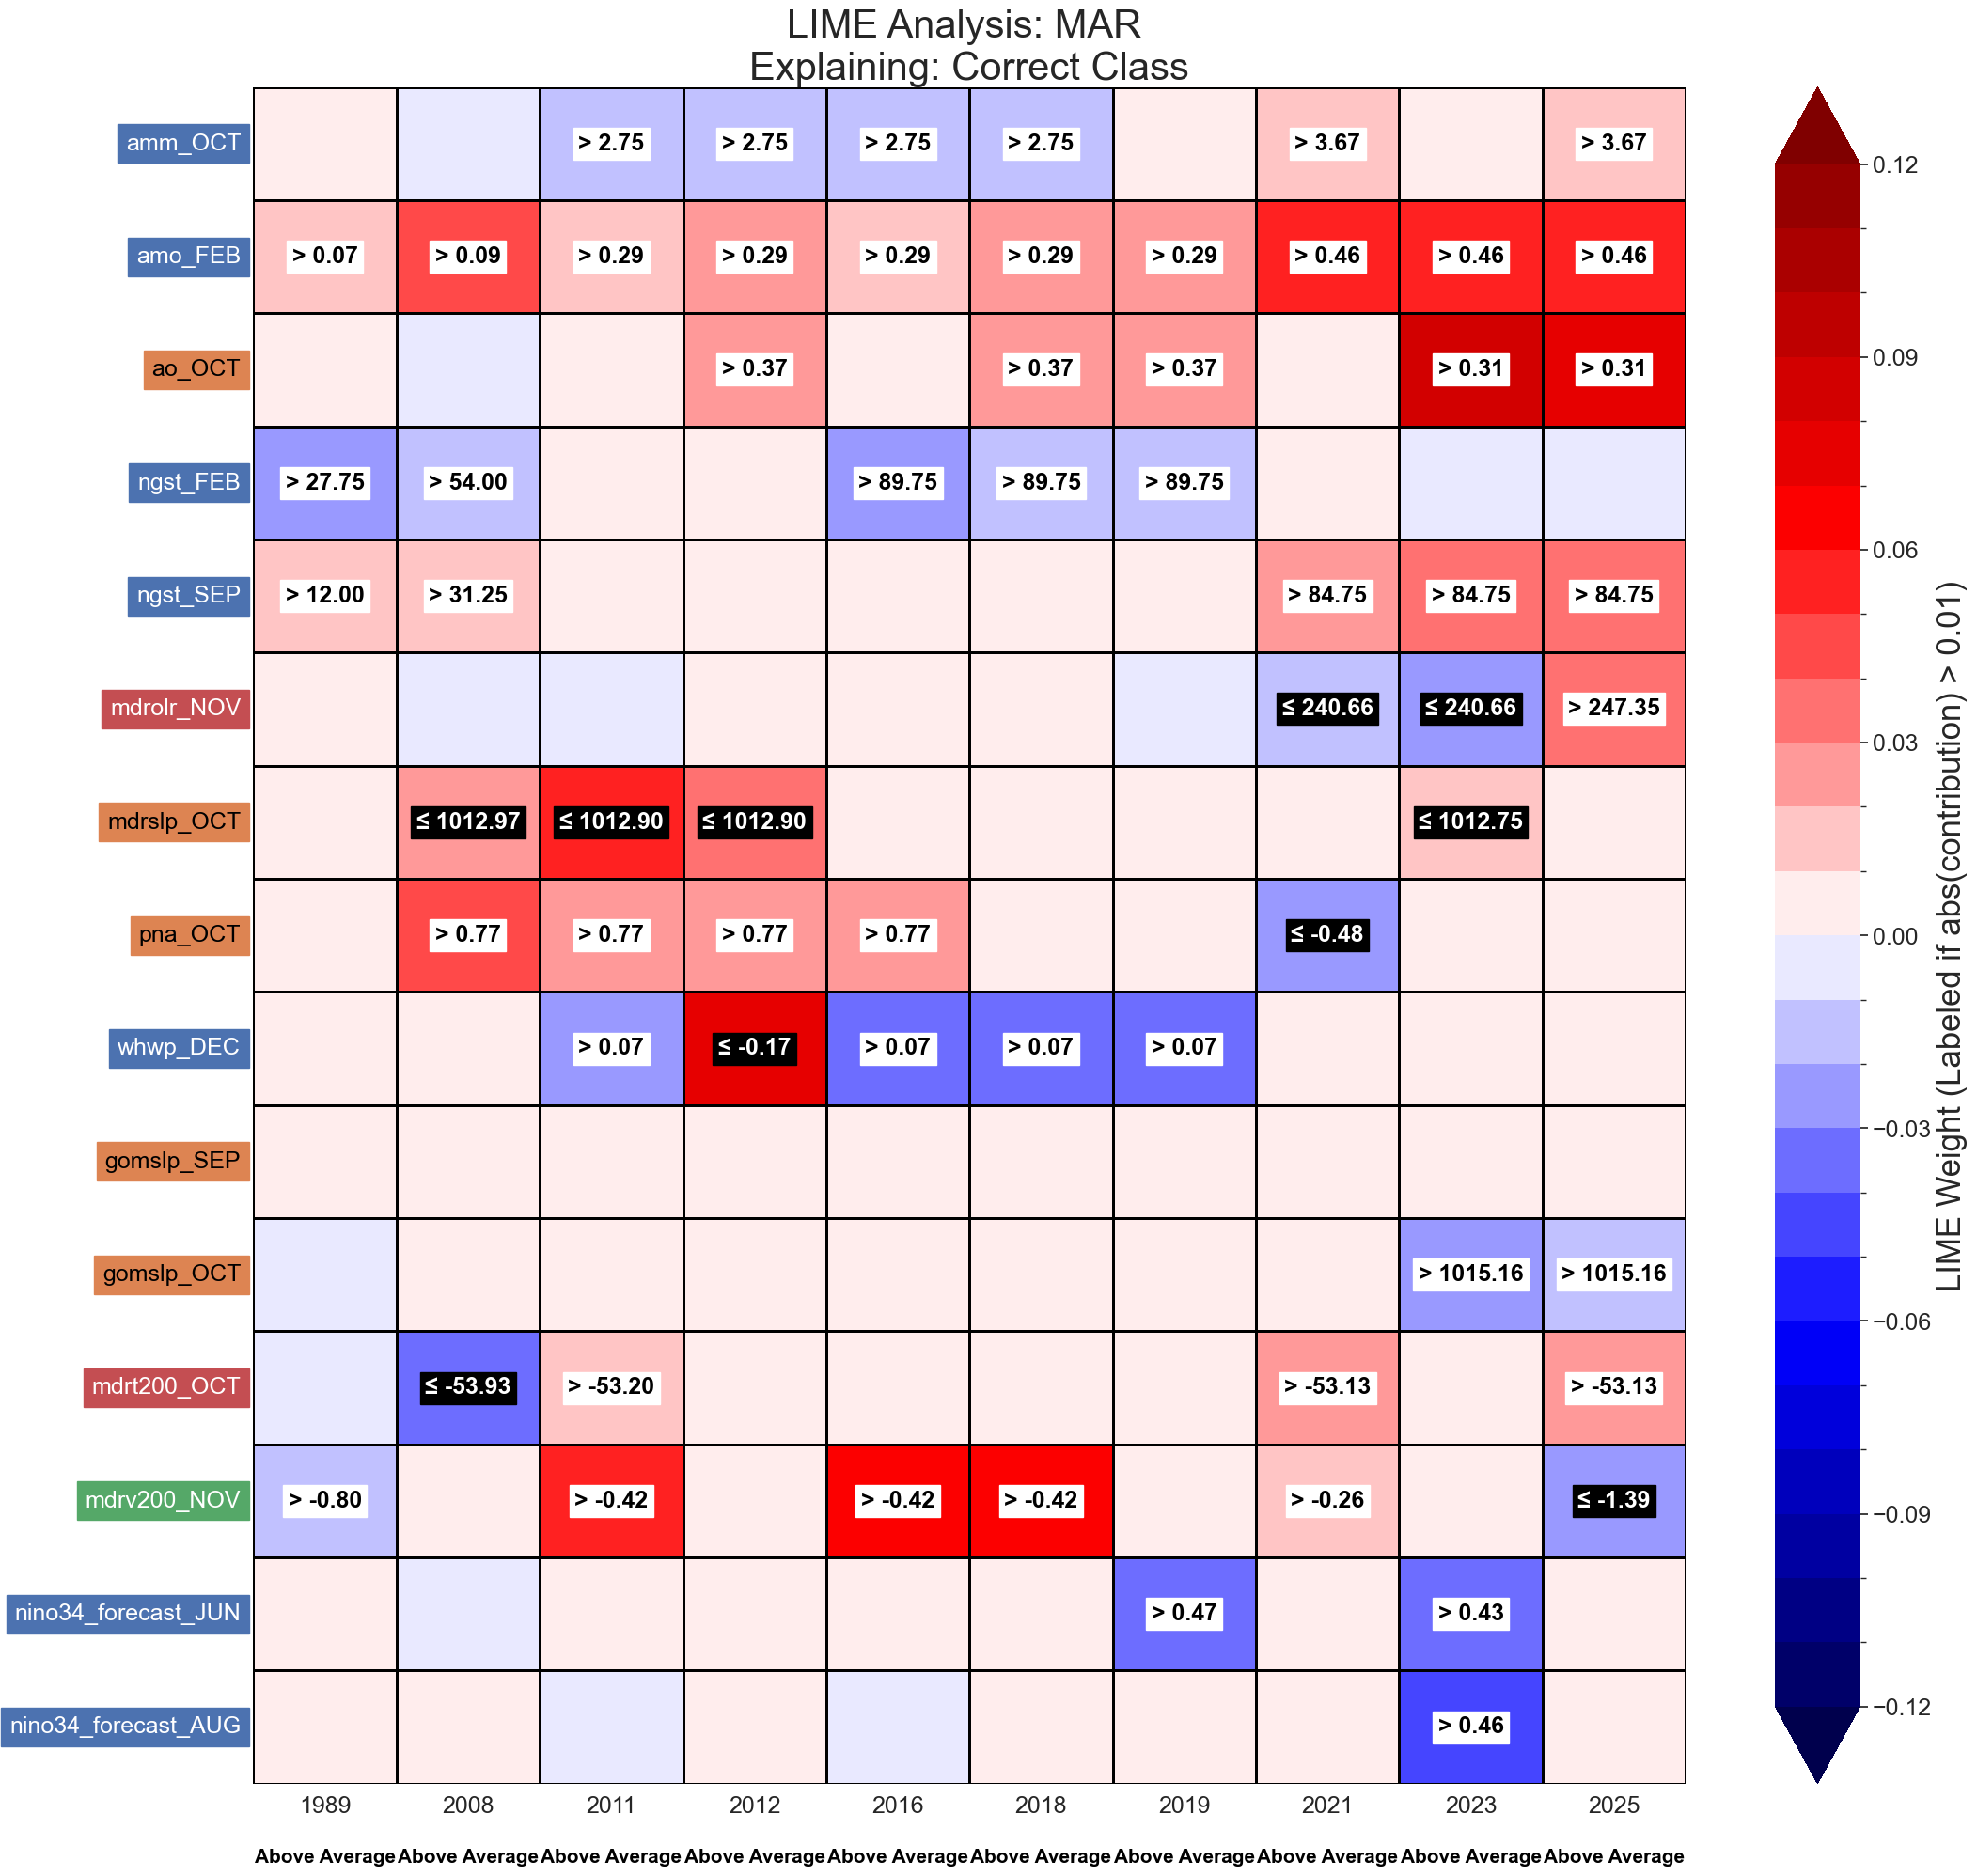

In [30]:
# ==========================================
# 1. Configuration & Flexibility
# ==========================================
target_month_idx = 3
month_key = allmonth[target_month_idx]
model_config = classset[target_month_idx]
best_features = model_config['features']
best_params = model_config['params']

# NEW: Choose which class to "interrogate"
# Options: 'Correct', 'Predicted', or a specific index: 0 (Below), 1 (Avg), 2 (Above), 3 (Ext)
explain_mode = 'Correct' 

# Data Containers
heatmap_data, years_list = [], []
threshold_labels = {}
correct_years, incorrect_years, bad_years, scorename = [], [], [], []

def clean_label_minimal(label):
    """Extracts only the inequality and value, removing the feature name."""
    # Regex to find things like '<= 0.5' or '>= -1.2'
    match = re.search(r'([<>]=?\s*-?\d+\.?\d*)', label)
    if match:
        return match.group(1).replace('<=', '≤').replace('>=', '≥')
    return ""

# ==========================================
# 2. Loop Through Recent Test Years
# ==========================================
yearrange = [1989, 2008, 2011, 2012, 2016, 2018, 2019, 2021, 2023, 2025] # range(2001, 2011) # Can do anything after 1981

for target_year in yearrange:
    c_start, c_end = get_climatology_bounds(target_year, base_year=1951)
    start_idx, end_idx = year_to_index(c_start), year_to_index(c_end) + 1
    
    X_train = features[best_features].iloc[start_idx:end_idx]
    y_train = actualscore[start_idx:end_idx]
    X_test  = features[best_features].iloc[[year_to_index(target_year)]]
    y_test  = actualscore[year_to_index(target_year)]
    # Account for Class Weighing
    window_years = range(c_start, c_end + 1)
    target_weight_type = "neutral"
    if target_year in [yearzz[i] for i in hotneu]: target_weight_type = "el_nino"
    if target_year in [yearzz[i] for i in coldneu]: target_weight_type = "la_nina"
    dynamic_weights = []
    for yr in window_years:
        weight = 1.0
        if target_weight_type == "el_nino" and yr in [yearzz[i] for i in hotneu]:
            weight = 2.0
        elif target_weight_type == "la_nina" and yr in [yearzz[i] for i in coldneu]:
            weight = 2.0
        elif target_weight_type == "neutral" and yr in [yearzz[i] for i in trueneu]:
            weight = 1.0 # Optional: slight boost to other neutral years
        dynamic_weights.append(weight)
    sample_weights = np.array(dynamic_weights)

    rf_explainer = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42)
    rf_explainer.fit(X_train, y_train, sample_weight = sample_weights)
    pred_class = rf_explainer.predict(X_test)[0]
    
    # Logic for Flexibility: Choose the class to explain
    if isinstance(explain_mode, int):
        explain_idx = explain_mode
    elif explain_mode == 'Correct':
        explain_idx = y_test
    else:
        explain_idx = pred_class
    
    correct_years.append(pred_class == y_test)
    incorrect_years.append(y_test > pred_class)
    bad_years.append(y_test < pred_class)
    scorename.append(type_labels[explain_idx])

    explainer = LimeTabularExplainer(X_train.values, feature_names=best_features, 
                                     class_names=type_labels, mode='classification', random_state=42)

    exp = explainer.explain_instance(X_test.iloc[0].values, rf_explainer.predict_proba,
                                    labels=(explain_idx,), num_features=len(best_features), num_samples=5000)

    lime_results = exp.as_list(label=explain_idx)
    lime_map = {re.search(r'([a-zA-Z0-9_]+)', f).group(1): w for f, w in lime_results}
    thresh_map = {re.search(r'([a-zA-Z0-9_]+)', f).group(1): f for f, w in lime_results}

    heatmap_data.append([lime_map.get(f, 0) for f in best_features])
    for f in best_features:
        if f in thresh_map:
            threshold_labels[(f, target_year)] = thresh_map[f]
    years_list.append(target_year)

# ==========================================
# 3. Visualization logic
# ==========================================
df_hm = pd.DataFrame(heatmap_data, columns=best_features, index=years_list).T
annot = df_hm.copy().astype(str)

for k, f in enumerate(df_hm.index):
    for l, y in enumerate(df_hm.columns):
        label = threshold_labels.get((f, y), "")
        if abs(df_hm.iloc[k,l]) > 0.01:
            annot.iloc[k,l] = clean_label_minimal(label) # Minimal annotation
        else:
            annot.iloc[k,l] = ""

bounds = np.linspace(-.12, .12, 25) 
cmap = mpl.colormaps['seismic']
my_norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(df_hm, cmap=cmap, norm=my_norm, annot=annot, fmt="", 
            annot_kws={"fontsize": 18, "fontweight": "bold"}, 
            linewidths=0.5, ax=ax, linecolor='black', linewidth=2)

# Y-Axis Categorical Coloring
for i, tick_label in enumerate(ax.get_yticklabels()):
    fname = df_hm.index[i].split('_')[0]
    if fname in ssttype: 
        tick_label.set_backgroundcolor('C0')
        tick_label.set_color('white')
    elif fname in prestype: 
        tick_label.set_backgroundcolor('C1')
        tick_label.set_color('black')
    elif fname in windtype: 
        tick_label.set_backgroundcolor('C2')
        tick_label.set_color('white')
    elif fname in othertype: 
        tick_label.set_backgroundcolor('C3')
        tick_label.set_color('white')

# Bottom Labels
for m, year in enumerate(df_hm.columns):
    if explain_mode=='Predicted':
        color = 'black' if correct_years[m] else ('blue' if incorrect_years[m] else 'red')
    elif explain_mode=='Correct':
        color='black'
    elif isinstance(explain_mode, int): 
        color = 'purple' # Distinct color if force-explaining a class
    ax.text(m+.5, len(best_features)+.7, s=scorename[m], fontsize=15, color=color, ha='center', fontweight='bold')

# Contrast Backgrounds
for text in ax.texts:
    txt = text.get_text()
    if '≤' in txt or '<' in txt:
        text.set_color('white'); text.set_backgroundcolor('black')
    elif '≥' in txt or '>' in txt:
        text.set_color('black'); text.set_backgroundcolor('white')
ax.tick_params(axis='both', labelsize=18) 
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label('LIME Weight (Labeled if abs(contribution) > 0.01)', size=25)
if isinstance(explain_mode, int): 
    ax.set_title(f"LIME Analysis: {month_key} \nExplaining: {classnames[explain_idx]} Class", fontsize=30)
    #ax.set_title(f"LIME Analysis: {month_key} \nExplaining: {classnames[explain_idx]} Class in {yearrange[0]} to {yearrange[-1]}", fontsize=30)
else:
    ax.set_title(f"LIME Analysis: {month_key} \nExplaining: {explain_mode} Class", fontsize=30)
    #ax.set_title(f"LIME Analysis: {month_key} \nExplaining: {explain_mode} Class in {yearrange[0]} to {yearrange[-1]}", fontsize=30)
plt.tight_layout()
plt.show()